# Health-Gait Manifest Loader

This notebook turns the Health-Gait silhouette manifest into a PyTorch `Dataset` and `DataLoader`.

The manifest is a CSV index. Each row describes one walking trial and points to a directory of frame images. The dataset reads one row, loads a contiguous frame window from that row's `frame_dir`, and returns a tensor shaped `[T, C, H, W]`.

The `DataLoader` then stacks several samples into `[B, T, C, H, W]`, which is the shape a video model usually expects before any model-specific rearrangement.

## Imports

The notebook imports the reusable Health&Gait loader package instead of defining a second notebook-local dataset class.

- The short path bootstrap lets the notebook run from either the repo root or `notebooks/`.
- `HealthGaitManifestDataset` is the low-level PyTorch dataset.
- `cody_jepa.data` provides path, manifest-preview, dataset, and DataLoader builder functions.
- Matplotlib is only for the visual sanity check at the end.
- PyTorch is used for the training handoff stub.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

NOTEBOOK_CWD = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_CWD if (NOTEBOOK_CWD / "src").exists() else NOTEBOOK_CWD.parent
for import_root in (PROJECT_ROOT, PROJECT_ROOT / "src"):
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

from cody_jepa.data import (
    DEFAULT_BATCH_SIZE,
    DEFAULT_CLIP_LENGTH,
    DEFAULT_IMAGE_SIZE,
    HealthGaitManifestDataset,
    build_healthgait_datasets,
    build_healthgait_loaders,
    find_repo_root,
    healthgait_manifest_path,
    preview_manifest,
)


## Path Setup

The manifest stores paths like `data/healthgait/raw/...`, which are relative to the repo root. Jupyter may start either in the repo root or inside `notebooks/`, so this cell finds the repo root once and anchors every manifest path to it.

In [2]:
REPO_ROOT = find_repo_root()
MANIFEST_CSV = healthgait_manifest_path(REPO_ROOT)

print(f"repo root: {REPO_ROOT}")
print(f"manifest:  {MANIFEST_CSV}")
print(f"exists:    {MANIFEST_CSV.exists()}")


repo root: /Users/theodoremui/dev/cody-jepa
manifest:  /Users/theodoremui/dev/cody-jepa/data/healthgait/manifests/silhouette_subject_split_seed0.csv
exists:    True


## Manifest Contract

Before writing the dataset class, inspect the CSV contract. The important columns are:

- `frame_dir`: directory containing ordered image frames for one trial.
- `num_frames`: how many frames the manifest builder counted in that directory.
- `split`: whether the trial belongs to `train` or `val`.
- `subject_id`: used for diagnostics, not as a self-supervised training label.

A good PyTorch dataset should treat each manifest row as one sample source, not as one frame.

In [3]:
preview_rows = preview_manifest(MANIFEST_CSV, n=3)

print("columns:", list(preview_rows[0].keys()) if preview_rows else [])
print("first row:")
preview_rows[0]


columns: ['subject_id', 'modality', 'gait_system', 'trial', 'frame_dir', 'num_frames', 'split']
first row:


{'subject_id': 'PA000',
 'modality': 'silhouette',
 'gait_system': 'FGS',
 'trial': 'WJ_1_YOLOV8',
 'frame_dir': 'data/healthgait/raw/Health_Gait/silhouette/PA000/FGS/WJ_1_YOLOV8',
 'num_frames': '96',
 'split': 'train'}

## Dataset Class

The dataset implementation now lives in `src/dataset.py`, so training scripts and notebooks use the same code path.

During `__init__`, it reads the manifest once and builds a lightweight list of samples. Each sample stores the row metadata and the sorted frame paths. This avoids crawling the filesystem again every time `__getitem__` runs.

During `__getitem__`, it loads only the frames needed for one clip window. That keeps memory use low: the full dataset is not loaded into RAM.


In [4]:
print(f"dataset class: {HealthGaitManifestDataset.__module__}.{HealthGaitManifestDataset.__name__}")


## Dataset Policy

`CLIP_LENGTH` controls how many consecutive frames each sample contains. `IMAGE_SIZE` controls the frame size after resizing.

For the train split, `random_windows=True` means the same trial can yield different temporal windows across epochs. For validation, `random_windows=False` always picks the center window, which makes validation metrics easier to compare between runs.

In [5]:
CLIP_LENGTH = DEFAULT_CLIP_LENGTH
IMAGE_SIZE = DEFAULT_IMAGE_SIZE

train_ds, val_ds = build_healthgait_datasets(
    MANIFEST_CSV,
    repo_root=REPO_ROOT,
    clip_length=CLIP_LENGTH,
    image_size=IMAGE_SIZE,
)

print(f"train clips: {len(train_ds)}")
print(f"val clips:   {len(val_ds)}")


train clips: 2506
val clips:   624


## Create DataLoaders

The dataset returns one sample. The `DataLoader` handles batching.

Start with `num_workers=0` in notebooks because it gives clearer error messages. In a training script, increasing `num_workers` can improve throughput once the loader is correct.

In [6]:
BATCH_SIZE = DEFAULT_BATCH_SIZE

train_loader, val_loader = build_healthgait_loaders(
    MANIFEST_CSV,
    repo_root=REPO_ROOT,
    clip_length=CLIP_LENGTH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
)


## Inspect One Batch

The key output is `video`. Its shape should be `[B, T, C, H, W]`:

- `B`: batch size.
- `T`: frames per clip.
- `C`: channels, which is `1` for grayscale silhouettes.
- `H`, `W`: resized frame height and width.

The pixel range should be `[0, 1]` because `_load_frame` divides the original `uint8` pixels by `255.0`.

In [8]:
batch = next(iter(train_loader))
video = batch["video"]

print(f"video shape: {tuple(video.shape)}")
print(f"dtype:       {video.dtype}")
print(f"min/max:     {float(video.min()):.3f} / {float(video.max()):.3f}")
print(f"subjects:    {list(batch['subject_id'])}")
print(f"trials:      {list(batch['trial'])}")

video shape: (4, 16, 1, 224, 224)
dtype:       torch.float32
min/max:     0.000 / 1.000
subjects:    ['PA265', 'PA025', 'PA039', 'PA138']
trials:      ['WJ_2_YOLOV8', 'WoJ_2_YOLOV8', 'WJ_1_YOLOV8', 'WoJ_1_YOLOV8']


## Visual Sanity Check

Numerical checks are not enough for video data. Displaying a few frames catches common mistakes: blank frames, wrong ordering, incorrect channel handling, or broken resizing.

This cell shows the first, middle, and last frame from the first clip in the batch.

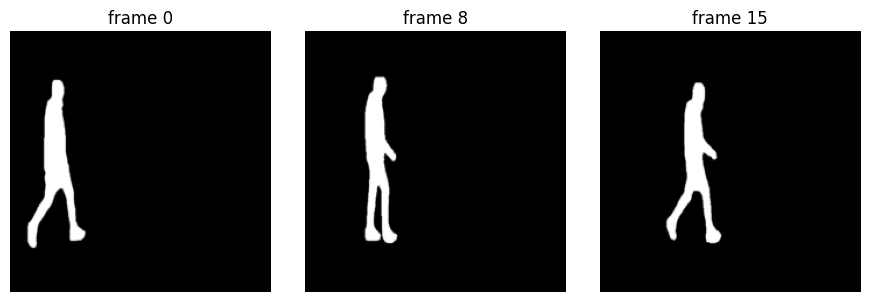

In [9]:
sample = video[0]  # [T, C, H, W]
frame_indices = [0, sample.shape[0] // 2, sample.shape[0] - 1]

fig, axes = plt.subplots(1, len(frame_indices), figsize=(9, 3))
for ax, frame_idx in zip(axes, frame_indices):
    ax.imshow(sample[frame_idx, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"frame {frame_idx}")
    ax.axis("off")

plt.tight_layout()

## Training Loop Shape Stub

This is only a handoff point to a model, not a full training loop.

For self-supervised CoDy-JEPA training, the model should consume `batch["video"]`. Keep `subject_id` and `trial` for diagnostics and debugging. Do not treat `subject_id` as a training label in the self-supervised objective.

In [10]:
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

for batch in train_loader:
    video = batch["video"].to(device)  # [B, T, C, H, W]
    print(f"send this tensor to the model: {tuple(video.shape)} on {device}")
    break

send this tensor to the model: (4, 16, 1, 224, 224) on mps
